# 1.4 Taxi Trip Cleanup

In this notebook we clean the taxi trip data provided by the city of chicago: https://data.cityofchicago.org/Transportation/Taxi-Trips-2024-/ajtu-isnz/about_data (downloaded on 05.05.2026).

In [1]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
from scipy.stats import zscore
from shapely.geometry import Polygon, Point

import geopandas as gpd
import h3

# reset working dir
import os
from pathlib import Path

In [2]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/anthony/Documents/Dokumente – MacBook Pro von Anthony/UNI/AAA/AAA_TA_2026


In [3]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Load data                               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

raw_data= pd.read_csv("data/trips/01_01_fetch_trip_data.csv")

In [4]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Data overview.                          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

print(f"Raw data shape: {raw_data.shape}")
print(f"Raw data info:")
print(raw_data.info())
print(f"Raw data columns: {list(raw_data.columns)}")
raw_data.head()

Raw data shape: (6825838, 23)
Raw data info:
<class 'pandas.DataFrame'>
RangeIndex: 6825838 entries, 0 to 6825837
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   trip_id                     str    
 1   taxi_id                     str    
 2   trip_start_timestamp        str    
 3   trip_end_timestamp          str    
 4   trip_seconds                float64
 5   trip_miles                  float64
 6   pickup_census_tract         float64
 7   dropoff_census_tract        float64
 8   pickup_community_area       float64
 9   dropoff_community_area      float64
 10  fare                        float64
 11  tips                        float64
 12  tolls                       float64
 13  extras                      float64
 14  trip_total                  float64
 15  payment_type                str    
 16  company                     str    
 17  pickup_centroid_latitude    float64
 18  pickup_centroid_longitude   

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,extras,trip_total,payment_type,company,pickup_centroid_latitude,pickup_centroid_longitude,pickup_centroid_location,dropoff_centroid_latitude,dropoff_centroid_longitude,dropoff_centroid_location
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,84957c8960b674346784746bbc1d48cafff4976b162323...,2025-01-01T00:00:00.000,2025-01-01T00:15:00.000,758.0,2.93,NaN,NaN,8.0,8.0,...,0.0,9.75,Prcard,Flash Cab,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,0cbf5c0f6aca3628d77c7b6fe89715757ed402a70b0f8b...,2025-01-01T00:00:00.000,2025-01-01T00:15:00.000,1233.0,13.66,NaN,NaN,76.0,6.0,...,5.0,48.60,Credit Card,Globe Taxi,41.980264,-87.913625,POINT (-87.913624596 41.9802643146),41.944227,-87.655998,POINT (-87.6559981815 41.9442266014)
2,060f692c4ca69e552c07a97c99715ad51112470e,e533bfdc483206f9c02c1c879a118d88f0a3ca1cd2703f...,2025-01-01T00:00:00.000,2025-01-01T00:00:00.000,6.0,0.00,NaN,NaN,6.0,6.0,...,0.0,30.50,Credit Card,Flash Cab,41.944227,-87.655998,POINT (-87.6559981815 41.9442266014),41.944227,-87.655998,POINT (-87.6559981815 41.9442266014)
3,0b2d1368456148b049af41dc8aa565d688081756,2d5029b701200a2ab66bd5071f743efe20a3036597d2b3...,2025-01-01T00:00:00.000,2025-01-01T00:00:00.000,11.0,0.00,NaN,NaN,77.0,77.0,...,0.0,25.62,Credit Card,Sun Taxi,41.986712,-87.663416,POINT (-87.6634164054 41.9867117999),41.986712,-87.663416,POINT (-87.6634164054 41.9867117999)
4,17365c83264f028a307ac70308d770fe03bcbcae,c3f8e0b6712bf3ea80e75ddde065b0ed42aa530e8c40cb...,2025-01-01T00:00:00.000,2025-01-01T00:15:00.000,985.0,3.22,NaN,NaN,8.0,7.0,...,0.0,55.00,Cash,City Service,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.922686,-87.649489,POINT (-87.6494887289 41.9226862843)


In [5]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Data type referencing                   #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# turn strings to numeric values
stringToNumeric = ["trip_miles", "fare", "tips", "tolls", "extras", "trip_total"]
raw_data[stringToNumeric] = raw_data[stringToNumeric].apply(
    lambda s: pd.to_numeric(
        s.astype(str)
         .str.replace("$", "", regex=False)
         .str.replace(",", ".", regex=False),
        errors="coerce"
    )
)


# Change type of Trip_Start_Timestamp and Trip_End_Timestamp to datetime object
raw_data["trip_start_timestamp"] = pd.to_datetime(
    raw_data["trip_start_timestamp"], format="%Y-%m-%dT%H:%M:%S.%f", errors="coerce"
)

raw_data["trip_end_timestamp"] = pd.to_datetime(
    raw_data["trip_end_timestamp"], format="%Y-%m-%dT%H:%M:%S.%f", errors="coerce"
)

raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6825838 entries, 0 to 6825837
Data columns (total 23 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   trip_id                     str           
 1   taxi_id                     str           
 2   trip_start_timestamp        datetime64[us]
 3   trip_end_timestamp          datetime64[us]
 4   trip_seconds                float64       
 5   trip_miles                  float64       
 6   pickup_census_tract         float64       
 7   dropoff_census_tract        float64       
 8   pickup_community_area       float64       
 9   dropoff_community_area      float64       
 10  fare                        float64       
 11  tips                        float64       
 12  tolls                       float64       
 13  extras                      float64       
 14  trip_total                  float64       
 15  payment_type                str           
 16  company                     s

In [6]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Check Time Range                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

print("Start Timestamp range:", raw_data["trip_start_timestamp"].min(), "to", raw_data["trip_start_timestamp"].max())

Start Timestamp range: 2025-01-01 00:00:00 to 2025-12-31 23:45:00


In [7]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Remove Duplicates                       #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# Check for duplicates
n_duplicates = raw_data.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")

# Check if any trip ids are duplicate
n_duplicate_trip_ids = raw_data["trip_id"].duplicated().sum()
print(f"Number of duplicated Trip IDs: {n_duplicate_trip_ids}")

Number of duplicate rows: 0
Number of duplicated Trip IDs: 0


In [8]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Remove N/A-values                       #
#  (only non-location data)               #
# # # # # # # # # # # # # # # # # # # # # #

# Check for NA values
na_summary = (
    raw_data
    .isna()
    .sum()
    .to_frame(name="Null Count")
    .assign(
        Null_Percent=lambda x: (x["Null Count"] / len(raw_data) * 100).round(2)
    )
)
na_summary

,Null Count,Null_Percent
trip_id,0,0.00
taxi_id,9,0.00
trip_start_timestamp,0,0.00
trip_end_timestamp,128,0.00
trip_seconds,1286,0.02
trip_miles,63,0.00
pickup_census_tract,3745888,54.88
dropoff_census_tract,3833965,56.17
pickup_community_area,186738,2.74
dropoff_community_area,587238,8.60


In [9]:
# Set the columns to check for NA values (e.g., exclude location columns)
columns_to_check = ['taxi_id', 'trip_end_timestamp', 'trip_seconds', 'trip_miles', "fare", "tips", "tolls", "extras", "trip_total"]  # change as needed

# Calculate how many rows would be removed if NA in these columns only
removed_na = raw_data.shape[0] - raw_data.dropna(subset=columns_to_check).shape[0]
removed_rel_share = (removed_na / raw_data.shape[0]) * 100

print(f'Dropping rows with NA in {columns_to_check} would remove {removed_na} rows ({removed_rel_share:.2f}%) of the dataset.')


Dropping rows with NA in ['taxi_id', 'trip_end_timestamp', 'trip_seconds', 'trip_miles', 'fare', 'tips', 'tolls', 'extras', 'trip_total'] would remove 12511 rows (0.18%) of the dataset.


In [10]:
# Remove na values, since only 0.18% of the dataset
raw_data = raw_data.dropna(subset=columns_to_check)

In [11]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Trip Data Cleaning                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# Trip miles < 0
n_negative_miles = (raw_data["trip_miles"] <= 0).sum()
print(f"Number of negative trip miles: {n_negative_miles}")

# Trip seconds < 60 (s)
n_seconds_less_min = (raw_data["trip_seconds"] < 60).sum()
print(f"Number of trips faster than 1 min: {n_seconds_less_min}")

# Remove negative trip miles and trips faster than 60s
raw_data = raw_data[((raw_data["trip_miles"] > 0) & (raw_data["trip_seconds"] >= 60))]

overlapping_trips = raw_data.groupby('taxi_id').apply(
    lambda group: group[
        (group['trip_start_timestamp'].lt(group['trip_end_timestamp'].shift(-1))) &
        (group['trip_end_timestamp'].gt(group['trip_start_timestamp'].shift(-1)))
    ]
)
print("Number of Taxi IDs with overlapping operation time periods:", len(overlapping_trips))
overlapping_trips

# assumption: if there are overlapping trips with the same taxi id, there was something wrong with all of these trips, so therefore we remove all of the overlapping trips
overlapping_trips_indices = overlapping_trips.index.get_level_values(1)
raw_data = raw_data.drop(overlapping_trips_indices, axis= 0)


Number of negative trip miles: 528445
Number of trips faster than 1 min: 381486
Number of Taxi IDs with overlapping operation time periods: 28320


In [12]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Price Data                              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# check for total_prices <= 0
# since tips, tolls and extras are dependent on the details of the trips and might be 0, it is okay for them to be 0.
# Fares are mandatory and have to be greater than 0

fare_check = (raw_data['fare'] <= 0).sum()
tips_check = (raw_data['tips'] < 0).sum()
tolls_check = (raw_data['tolls'] < 0).sum()
extras_check = (raw_data['extras'] < 0).sum()
print("Number of entries with fares <= 0:", fare_check)
print("Number of entries with tips <= 0:", tips_check)
print("Number of entries with tolls <= 0:", tolls_check)
print("Number of entries with extras <= 0:", extras_check)

# remove negative or 0 fares
raw_data = raw_data[raw_data["fare"] > 0]
raw_data.reset_index(drop=True)

Number of entries with fares <= 0: 1455
Number of entries with tips <= 0: 0
Number of entries with tolls <= 0: 0
Number of entries with extras <= 0: 0


,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,extras,trip_total,payment_type,company,pickup_centroid_latitude,pickup_centroid_longitude,pickup_centroid_location,dropoff_centroid_latitude,dropoff_centroid_longitude,dropoff_centroid_location
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,84957c8960b674346784746bbc1d48cafff4976b162323...,2025-01-01 00:00:00,2025-01-01 00:15:00,758.0,2.93,NaN,NaN,8.0,8.0,...,0.0,9.75,Prcard,Flash Cab,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,0cbf5c0f6aca3628d77c7b6fe89715757ed402a70b0f8b...,2025-01-01 00:00:00,2025-01-01 00:15:00,1233.0,13.66,NaN,NaN,76.0,6.0,...,5.0,48.60,Credit Card,Globe Taxi,41.980264,-87.913625,POINT (-87.913624596 41.9802643146),41.944227,-87.655998,POINT (-87.6559981815 41.9442266014)
2,17365c83264f028a307ac70308d770fe03bcbcae,c3f8e0b6712bf3ea80e75ddde065b0ed42aa530e8c40cb...,2025-01-01 00:00:00,2025-01-01 00:15:00,985.0,3.22,NaN,NaN,8.0,7.0,...,0.0,55.00,Cash,City Service,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.922686,-87.649489,POINT (-87.6494887289 41.9226862843)
3,1c629303d7f08492d97e13fabe6a0d1d81e6c9c5,c8f57a1150c210a9e6b3fcfb24c3d6d0a43d1879b4b979...,2025-01-01 00:00:00,2025-01-01 00:15:00,652.0,3.24,NaN,NaN,22.0,7.0,...,0.0,15.67,Mobile,Tac - Yellow Cab Association,41.922761,-87.699155,POINT (-87.6991553432 41.9227606205),41.922686,-87.649489,POINT (-87.6494887289 41.9226862843)
4,1cb48762978a475116ec833c0e4de8ed2ac88e14,88d8896a85cf755c4fb03711d495dc47ca8109196cdef6...,2025-01-01 00:00:00,2025-01-01 00:15:00,803.0,6.09,NaN,NaN,8.0,3.0,...,1.0,18.50,Cash,City Service,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.965812,-87.655879,POINT (-87.6558787862 41.96581197)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6188264,f19c5c32205e7fb37b7ff564da1146484259f8fb,3ae83cc261cea27eafc3d9b18bbc93100c03762e8b6971...,2025-12-31 23:45:00,2026-01-01 00:00:00,960.0,1.70,1.703108e+10,NaN,8.0,NaN,...,0.0,9.50,Cash,Transit Administrative Center Inc,41.895033,-87.619711,POINT (-87.6197106717 41.8950334495),NaN,NaN,NaN
6188265,f1f4fd1497483c42e0f597b0d4e23fef46512bd0,8ac81cfa2ee2c29b19f8fa21ed92b908d46bedc9d4055c...,2025-12-31 23:45:00,2025-12-31 23:45:00,480.0,1.10,NaN,NaN,32.0,32.0,...,1.0,7.75,Cash,Choice Taxi Association Inc,41.878866,-87.625192,POINT (-87.6251921424 41.8788655841),41.878866,-87.625192,POINT (-87.6251921424 41.8788655841)
6188266,f25fea09e509dc84b861f98c47cb557701718ffd,54f9ba36584d6915e95cdf3394cdc46ed49c4a57cb0eb2...,2025-12-31 23:45:00,2026-01-01 00:00:00,632.0,3.59,NaN,NaN,32.0,33.0,...,1.0,13.50,Cash,Sun Taxi,41.878866,-87.625192,POINT (-87.6251921424 41.8788655841),41.857184,-87.620335,POINT (-87.6203346241 41.8571838585)
6188267,f6181757bf371eb4d0480e052ed2723d58750bfc,17a313ad40ea410818634782c7202abda7ce5289dc03f9...,2025-12-31 23:45:00,2026-01-01 00:00:00,679.0,2.71,NaN,NaN,8.0,24.0,...,0.0,13.75,Mobile,Flash Cab,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.901207,-87.676356,POINT (-87.6763559892 41.9012069941)


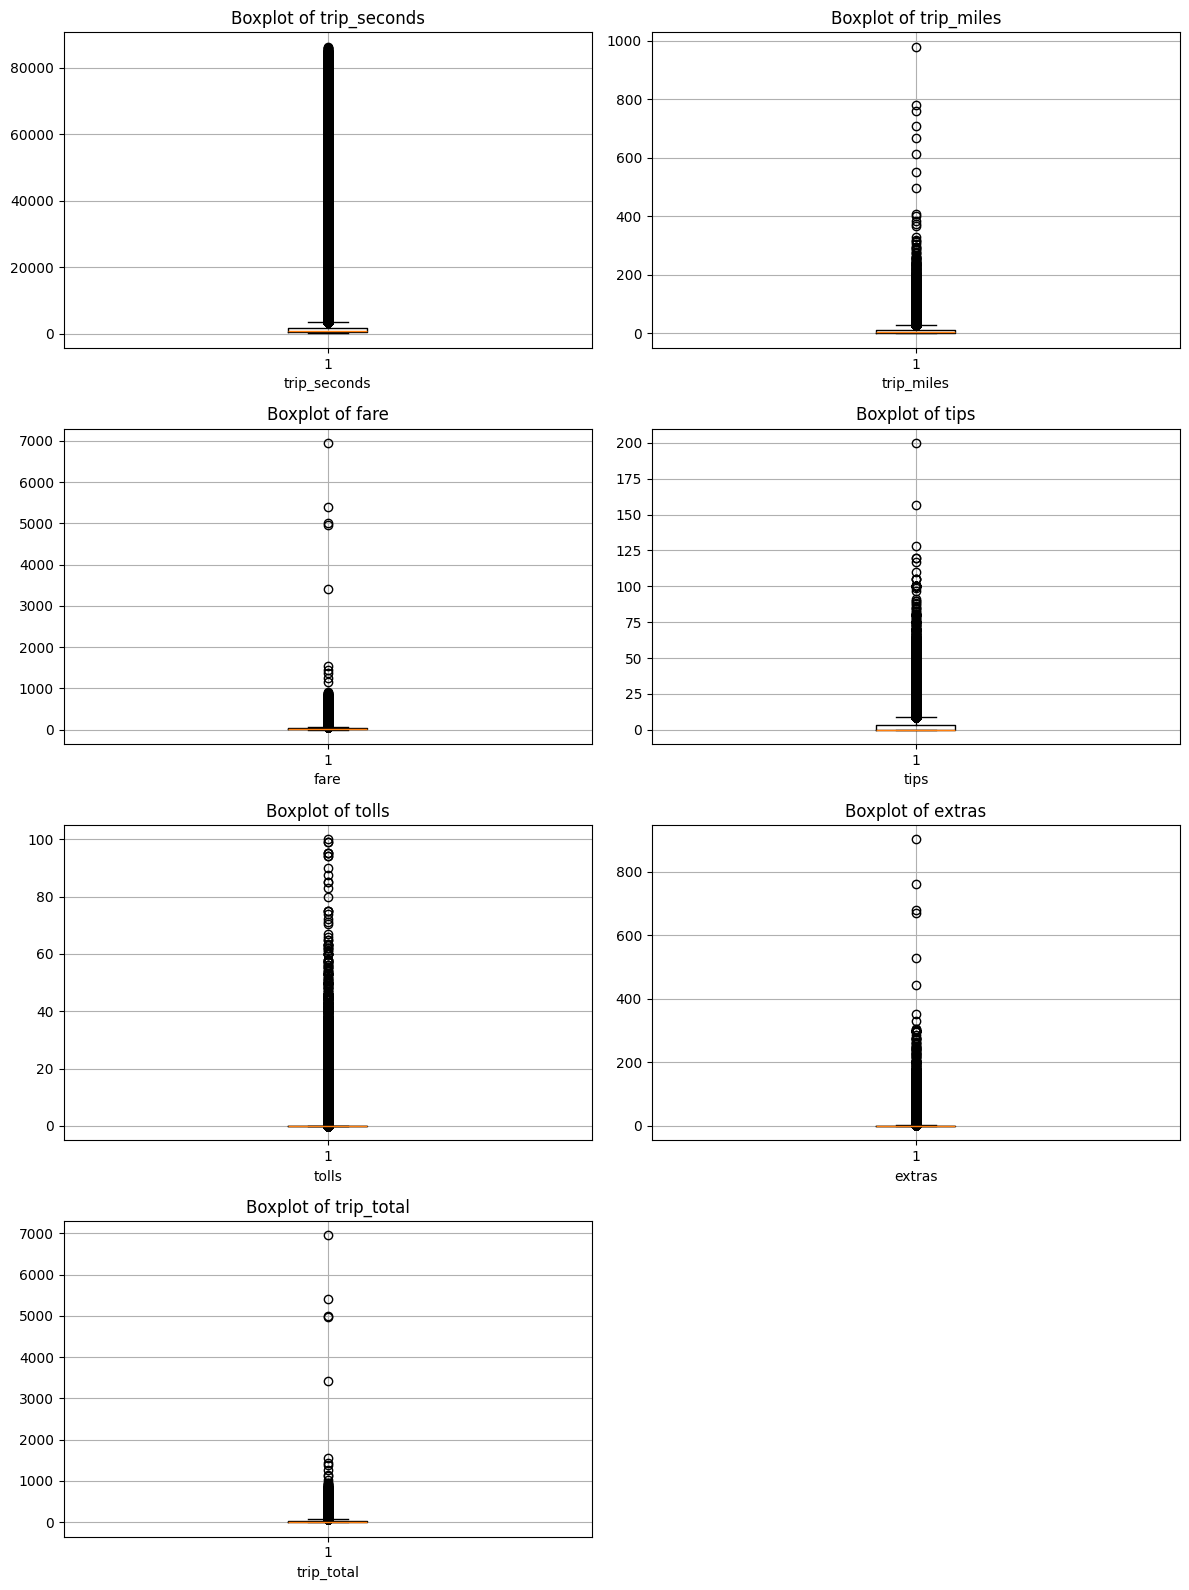

In [13]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Outlier Detection                       #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

numeric_columns = ["trip_seconds", "trip_miles", "fare", "tips", "tolls", "extras", "trip_total"]

# 2 plots per row
rows = math.ceil(len(numeric_columns) / 2)

fig, axes = plt.subplots(rows, 2, figsize=(12, rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    data = pd.to_numeric(raw_data[col], errors='coerce').dropna()
    axes[i].boxplot(data, vert=True)
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel(col)
    axes[i].grid(True)

# Remove any unused axes
for j in range(len(numeric_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [14]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Outlier Removal: Statistical Solution   #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

zscore_threshold = 2
outlier_indices_per_column = {}
all_outlier_indices = set()

# remove outliers based on z-score
for col in numeric_columns:
    # Replace zeros with NaN and filter out non-positive values
    safe_col = raw_data[col].replace(0, np.nan)
    safe_col = safe_col[safe_col > 0]
    
    if safe_col.empty:
        continue
    
    # Log-transform and compute z-score
    log_transformed = np.log(safe_col)
    zscores = np.abs(zscore(log_transformed))
    zscore_series = pd.Series(zscores, index=log_transformed.index)

    # Find outliers
    outlier_indices = zscore_series[zscore_series > zscore_threshold].index
    outlier_indices_per_column[col] = list(outlier_indices)
    all_outlier_indices.update(outlier_indices)

    print(f"--> {len(outlier_indices)} outliers detected in '{col}'")

# Drop all outliers at once
total_rows = len(raw_data) # for dropped percentage of dataset
df_cleaned = raw_data.drop(index=all_outlier_indices).reset_index(drop=True)

removed_rows = len(all_outlier_indices)
removed_percentage = round((removed_rows / total_rows) * 100, 2)

print(f"\nOutlier detection completed. Total rows removed: {len(all_outlier_indices)}, {removed_percentage}%")

--> 219894 outliers detected in 'trip_seconds'
--> 94276 outliers detected in 'trip_miles'
--> 55121 outliers detected in 'fare'
--> 52309 outliers detected in 'tips'
--> 2683 outliers detected in 'tolls'
--> 127168 outliers detected in 'extras'
--> 96280 outliers detected in 'trip_total'

Outlier detection completed. Total rows removed: 444100, 7.18%


In [16]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Location data imputation                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# --- 1) Fix comma-decimal coordinates ---
coord_cols = [
    "pickup_centroid_latitude", "pickup_centroid_longitude",
    "dropoff_centroid_latitude", "dropoff_centroid_longitude"
]

raw_data[coord_cols] = raw_data[coord_cols].apply(
    lambda s: pd.to_numeric(s.astype(str).str.replace(",", ".", regex=False),
                            errors="coerce")
)

# --- 2) Load tract polygons ---
# The taxi data uses 2010 census tract IDs (Cook County only, all 17031XXXXX).
# The 2010 county-specific TIGER file already contains only Cook County tracts,
# so no county filter is needed. GEOID10 is renamed to GEOID for consistency.
_tracts_raw = gpd.read_file("data/Census_Tracts_Chicago.geojson")
tracts = _tracts_raw.rename(columns={"census_t_1": "GEOID"}).to_crs(4326)
TRACT_COL = "GEOID"

centroids = tracts.set_index(TRACT_COL).geometry.centroid

# --- 3) Helper: fill missing tracts from coords ---
def fill_tract(lat_col, lon_col, tract_col):
    mask = raw_data[tract_col].isna() & raw_data[lat_col].notna()
    if mask.any():
        pts = gpd.GeoDataFrame(
            geometry=gpd.points_from_xy(raw_data.loc[mask, lon_col],
                                        raw_data.loc[mask, lat_col]),
            crs=4326,
            index=raw_data.index[mask]
        )
        joined = gpd.sjoin(pts, tracts[[TRACT_COL, "geometry"]],
                           how="left", predicate="within")
        raw_data.loc[joined.index, tract_col] = joined[TRACT_COL].values

# --- 4) Helper: fill missing coords from tract ---
def fill_coords(lat_col, lon_col, tract_col):
    mask = raw_data[tract_col].notna() & raw_data[lat_col].isna()
    if mask.any():
        c = centroids.reindex(raw_data.loc[mask, tract_col].astype(str))
        raw_data.loc[mask, lat_col] = c.y.values
        raw_data.loc[mask, lon_col] = c.x.values

# --- 5) Apply ---
raw_data["pickup_census_tract"] = raw_data["pickup_census_tract"].astype("string")
raw_data["dropoff_census_tract"] = raw_data["dropoff_census_tract"].astype("string")

fill_tract("pickup_centroid_latitude", "pickup_centroid_longitude", "pickup_census_tract")
fill_tract("dropoff_centroid_latitude", "dropoff_centroid_longitude", "dropoff_census_tract")

fill_coords("pickup_centroid_latitude", "pickup_centroid_longitude", "pickup_census_tract")
fill_coords("dropoff_centroid_latitude", "dropoff_centroid_longitude", "dropoff_census_tract")

print(raw_data.isna().sum())


/var/folders/2y/_wxqgfb555717vrjqjj3kyvm0000gn/T/ipykernel_22057/3033292120.py:26: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = tracts.set_index(TRACT_COL).geometry.centroid


trip_id                            0
taxi_id                            0
trip_start_timestamp               0
trip_end_timestamp                 0
trip_seconds                       0
trip_miles                         0
pickup_census_tract           109052
dropoff_census_tract          474639
pickup_community_area         109877
dropoff_community_area        511148
fare                               0
tips                               0
tolls                              0
extras                             0
trip_total                         0
payment_type                       0
company                            0
pickup_centroid_latitude      109158
pickup_centroid_longitude     109158
pickup_centroid_location      109158
dropoff_centroid_latitude     480448
dropoff_centroid_longitude    480448
dropoff_centroid_location     480448
dtype: int64


In [17]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Remove N/A-values                       #
#  (only non-location data)               #
# # # # # # # # # # # # # # # # # # # # # #

# Check for NA values
na_summary = (
    raw_data
    .isna()
    .sum()
    .to_frame(name="Null Count")
    .assign(
        Null_Percent=lambda x: (x["Null Count"] / len(raw_data) * 100).round(2)
    )
)
na_summary

,Null Count,Null_Percent
trip_id,0,0.00
taxi_id,0,0.00
trip_start_timestamp,0,0.00
trip_end_timestamp,0,0.00
trip_seconds,0,0.00
trip_miles,0,0.00
pickup_census_tract,109052,1.76
dropoff_census_tract,474639,7.67
pickup_community_area,109877,1.78
dropoff_community_area,511148,8.26


In [18]:
# Set the columns to check for NA values (e.g., exclude location columns)
columns_to_remove = ["pickup_census_tract", "dropoff_census_tract", "pickup_community_area", "dropoff_community_area", "pickup_centroid_latitude", "pickup_centroid_longitude", "pickup_centroid_location", "dropoff_centroid_latitude", "dropoff_centroid_longitude", "dropoff_centroid_location"]

# Calculate how many rows would be removed if NA in these columns only
removed_na = raw_data.shape[0] - raw_data.dropna(subset=columns_to_remove).shape[0]
removed_rel_share = (removed_na / raw_data.shape[0]) * 100

print(f'Dropping rows with NA in {columns_to_remove} would remove {removed_na} rows ({removed_rel_share:.2f}%) of the dataset of {raw_data.shape[0]} rows.')


Dropping rows with NA in ['pickup_census_tract', 'dropoff_census_tract', 'pickup_community_area', 'dropoff_community_area', 'pickup_centroid_latitude', 'pickup_centroid_longitude', 'pickup_centroid_location', 'dropoff_centroid_latitude', 'dropoff_centroid_longitude', 'dropoff_centroid_location'] would remove 551090 rows (8.91%) of the dataset of 6188269 rows.


### Removing all N/A values from the dataset would remove another 8.91% of the dataset. We consider this as acceptable (since the entirety of the dataset is still 6.19m records), therefore we throw out all the N/A values.

In [19]:
# Remove na values, see upper cell
raw_data = raw_data.dropna(subset=columns_to_remove)

In [20]:
raw_data.head()

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,extras,trip_total,payment_type,company,pickup_centroid_latitude,pickup_centroid_longitude,pickup_centroid_location,dropoff_centroid_latitude,dropoff_centroid_longitude,dropoff_centroid_location
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,84957c8960b674346784746bbc1d48cafff4976b162323...,2025-01-01,2025-01-01 00:15:00,758.0,2.93,17031081000,17031081000,8.0,8.0,...,0.0,9.75,Prcard,Flash Cab,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,0cbf5c0f6aca3628d77c7b6fe89715757ed402a70b0f8b...,2025-01-01,2025-01-01 00:15:00,1233.0,13.66,17031760900,17031062200,76.0,6.0,...,5.0,48.60,Credit Card,Globe Taxi,41.980264,-87.913625,POINT (-87.913624596 41.9802643146),41.944227,-87.655998,POINT (-87.6559981815 41.9442266014)
4,17365c83264f028a307ac70308d770fe03bcbcae,c3f8e0b6712bf3ea80e75ddde065b0ed42aa530e8c40cb...,2025-01-01,2025-01-01 00:15:00,985.0,3.22,17031081000,17031071100,8.0,7.0,...,0.0,55.00,Cash,City Service,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.922686,-87.649489,POINT (-87.6494887289 41.9226862843)
5,1c629303d7f08492d97e13fabe6a0d1d81e6c9c5,c8f57a1150c210a9e6b3fcfb24c3d6d0a43d1879b4b979...,2025-01-01,2025-01-01 00:15:00,652.0,3.24,17031221300,17031071100,22.0,7.0,...,0.0,15.67,Mobile,Tac - Yellow Cab Association,41.922761,-87.699155,POINT (-87.6991553432 41.9227606205),41.922686,-87.649489,POINT (-87.6494887289 41.9226862843)
6,1cb48762978a475116ec833c0e4de8ed2ac88e14,88d8896a85cf755c4fb03711d495dc47ca8109196cdef6...,2025-01-01,2025-01-01 00:15:00,803.0,6.09,17031081000,17031031600,8.0,3.0,...,1.0,18.50,Cash,City Service,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.965812,-87.655879,POINT (-87.6558787862 41.96581197)


In [23]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Spatial Resolution                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# Area-weighted Census Tract → H3 Mapping
# For each census tract, finds all H3 cells that overlap it and computes
# intersection-area weights (summing to 1 per tract). Trips are later
# probabilistically assigned to a hexagon based on this distribution.

_tracts_raw = gpd.read_file("data/Census_Tracts_Chicago.geojson")
tracts = _tracts_raw.rename(columns={"census_t_1": "GEOID"}).to_crs(4326)
TRACT_COL = "GEOID"

def build_hex_coverage(tracts_gdf, res_level, tract_col=TRACT_COL):
    rows = []
    for _, row in tracts_gdf.iterrows():
        tract_id = row[tract_col]
        geom = row.geometry
        parts = list(geom.geoms) if geom.geom_type == 'MultiPolygon' else [geom]
        cells = set()
        for part in parts:
            cells.update(h3.geo_to_cells(part.__geo_interface__, res_level))
        if not cells:  # fallback for tracts smaller than one H3 cell
            c = geom.centroid
            cells = {h3.latlng_to_cell(c.y, c.x, res_level)}
        candidates = set(cells)
        for cell in cells:
            candidates.update(h3.grid_disk(cell, 1))  # expand by 1 ring to catch border cells
        for cell in candidates:
            hex_poly = Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(cell)])
            area = geom.intersection(hex_poly).area
            if area > 0:
                rows.append({'tract_id': tract_id, 'h3_cell': cell, 'area': area})
    coverage = pd.DataFrame(rows)
    total = coverage.groupby('tract_id')['area'].transform('sum')
    coverage['weight'] = coverage['area'] / total
    return coverage[['tract_id', 'h3_cell', 'weight']]

resolutions = {'low': 6, 'medium': 7, 'high': 8}

coverage = {}
for res_name, res_level in resolutions.items():
    print(f"Building {res_name} resolution (level {res_level}) …", flush=True)
    coverage[res_name] = build_hex_coverage(tracts, res_level)
    print(f"  → {len(coverage[res_name]):,} tract-cell pairs")

Building low resolution (level 6) …
  → 1,172 tract-cell pairs
Building medium resolution (level 7) …
  → 1,736 tract-cell pairs
Building high resolution (level 8) …
  → 3,650 tract-cell pairs


In [24]:
# Pinned locations override area-weighting for tracts where trips consistently
# go to one specific point (e.g. O'Hare terminal rather than the whole tract).
pinned_locations = {
    "ohare_terminal":     (41.9786, -87.9048),
    "big_marsh_entrance": (41.668,  -87.554),
}

pts = gpd.GeoDataFrame(
    {"name": list(pinned_locations.keys())},
    geometry=[Point(lon, lat) for lat, lon in pinned_locations.values()],
    crs=4326,
)
joined = gpd.sjoin(pts, tracts[[TRACT_COL, "geometry"]], how="left", predicate="within")
tract_overrides = {
    row[TRACT_COL]: [pinned_locations[row["name"]]]
    for _, row in joined.iterrows()
    if pd.notna(row[TRACT_COL])
}

print("Pinned tract overrides:")
for tid, locs in tract_overrides.items():
    print(f"  tract {tid}  →  {locs}")

# Probabilistically assign each trip to an H3 cell based on its census tract's
# area-weight distribution; pinned tracts go to their exact hexagon instead.
rng = np.random.default_rng(42)

for res_name, res_level in resolutions.items():
    lookup = {
        tid: (grp['h3_cell'].values, grp['weight'].values)
        for tid, grp in coverage[res_name].groupby('tract_id')
    }
    for tract_id, locs in tract_overrides.items():
        cells = np.array(list({h3.latlng_to_cell(lat, lon, res_level) for lat, lon in locs}))
        lookup[tract_id] = (cells, np.ones(len(cells)) / len(cells))

    for direction in ('pickup', 'dropoff'):
        tract_col_name = f'{direction}_census_tract'
        h3_col = f'{direction}_h3_{res_name}_resolution'
        result = pd.Series(index=raw_data.index, dtype=object)

        for tract_id, idx in raw_data.groupby(tract_col_name).groups.items():
            key = str(int(float(tract_id))) if pd.notna(tract_id) else None
            if key is None or key not in lookup:
                continue
            cells, weights = lookup[key]
            result[idx] = rng.choice(cells, size=len(idx), p=weights)

        raw_data[h3_col] = result

    # Fallback: assign H3 directly from coordinates for any rows still null
    # (trips whose centroid falls just outside all tract polygon boundaries)
    for direction, lat_col, lon_col in [
        ('pickup',  'pickup_centroid_latitude',  'pickup_centroid_longitude'),
        ('dropoff', 'dropoff_centroid_latitude', 'dropoff_centroid_longitude'),
    ]:
        h3_col = f'{direction}_h3_{res_name}_resolution'
        mask = raw_data[h3_col].isna()
        if mask.any():
            raw_data.loc[mask, h3_col] = [
                h3.latlng_to_cell(lat, lon, res_level)
                for lat, lon in zip(
                    raw_data.loc[mask, lat_col],
                    raw_data.loc[mask, lon_col],
                )
            ]

    pickup_na = raw_data[f'pickup_h3_{res_name}_resolution'].isna().sum()
    dropoff_na = raw_data[f'dropoff_h3_{res_name}_resolution'].isna().sum()
    print(f"{res_name}: pickup NAs={pickup_na:,}  dropoff NAs={dropoff_na:,}")


Pinned tract overrides:
  tract 17031760900  →  [(41.9786, -87.9048)]
  tract 17031510400  →  [(41.668, -87.554)]
low: pickup NAs=0  dropoff NAs=0
medium: pickup NAs=0  dropoff NAs=0
high: pickup NAs=0  dropoff NAs=0


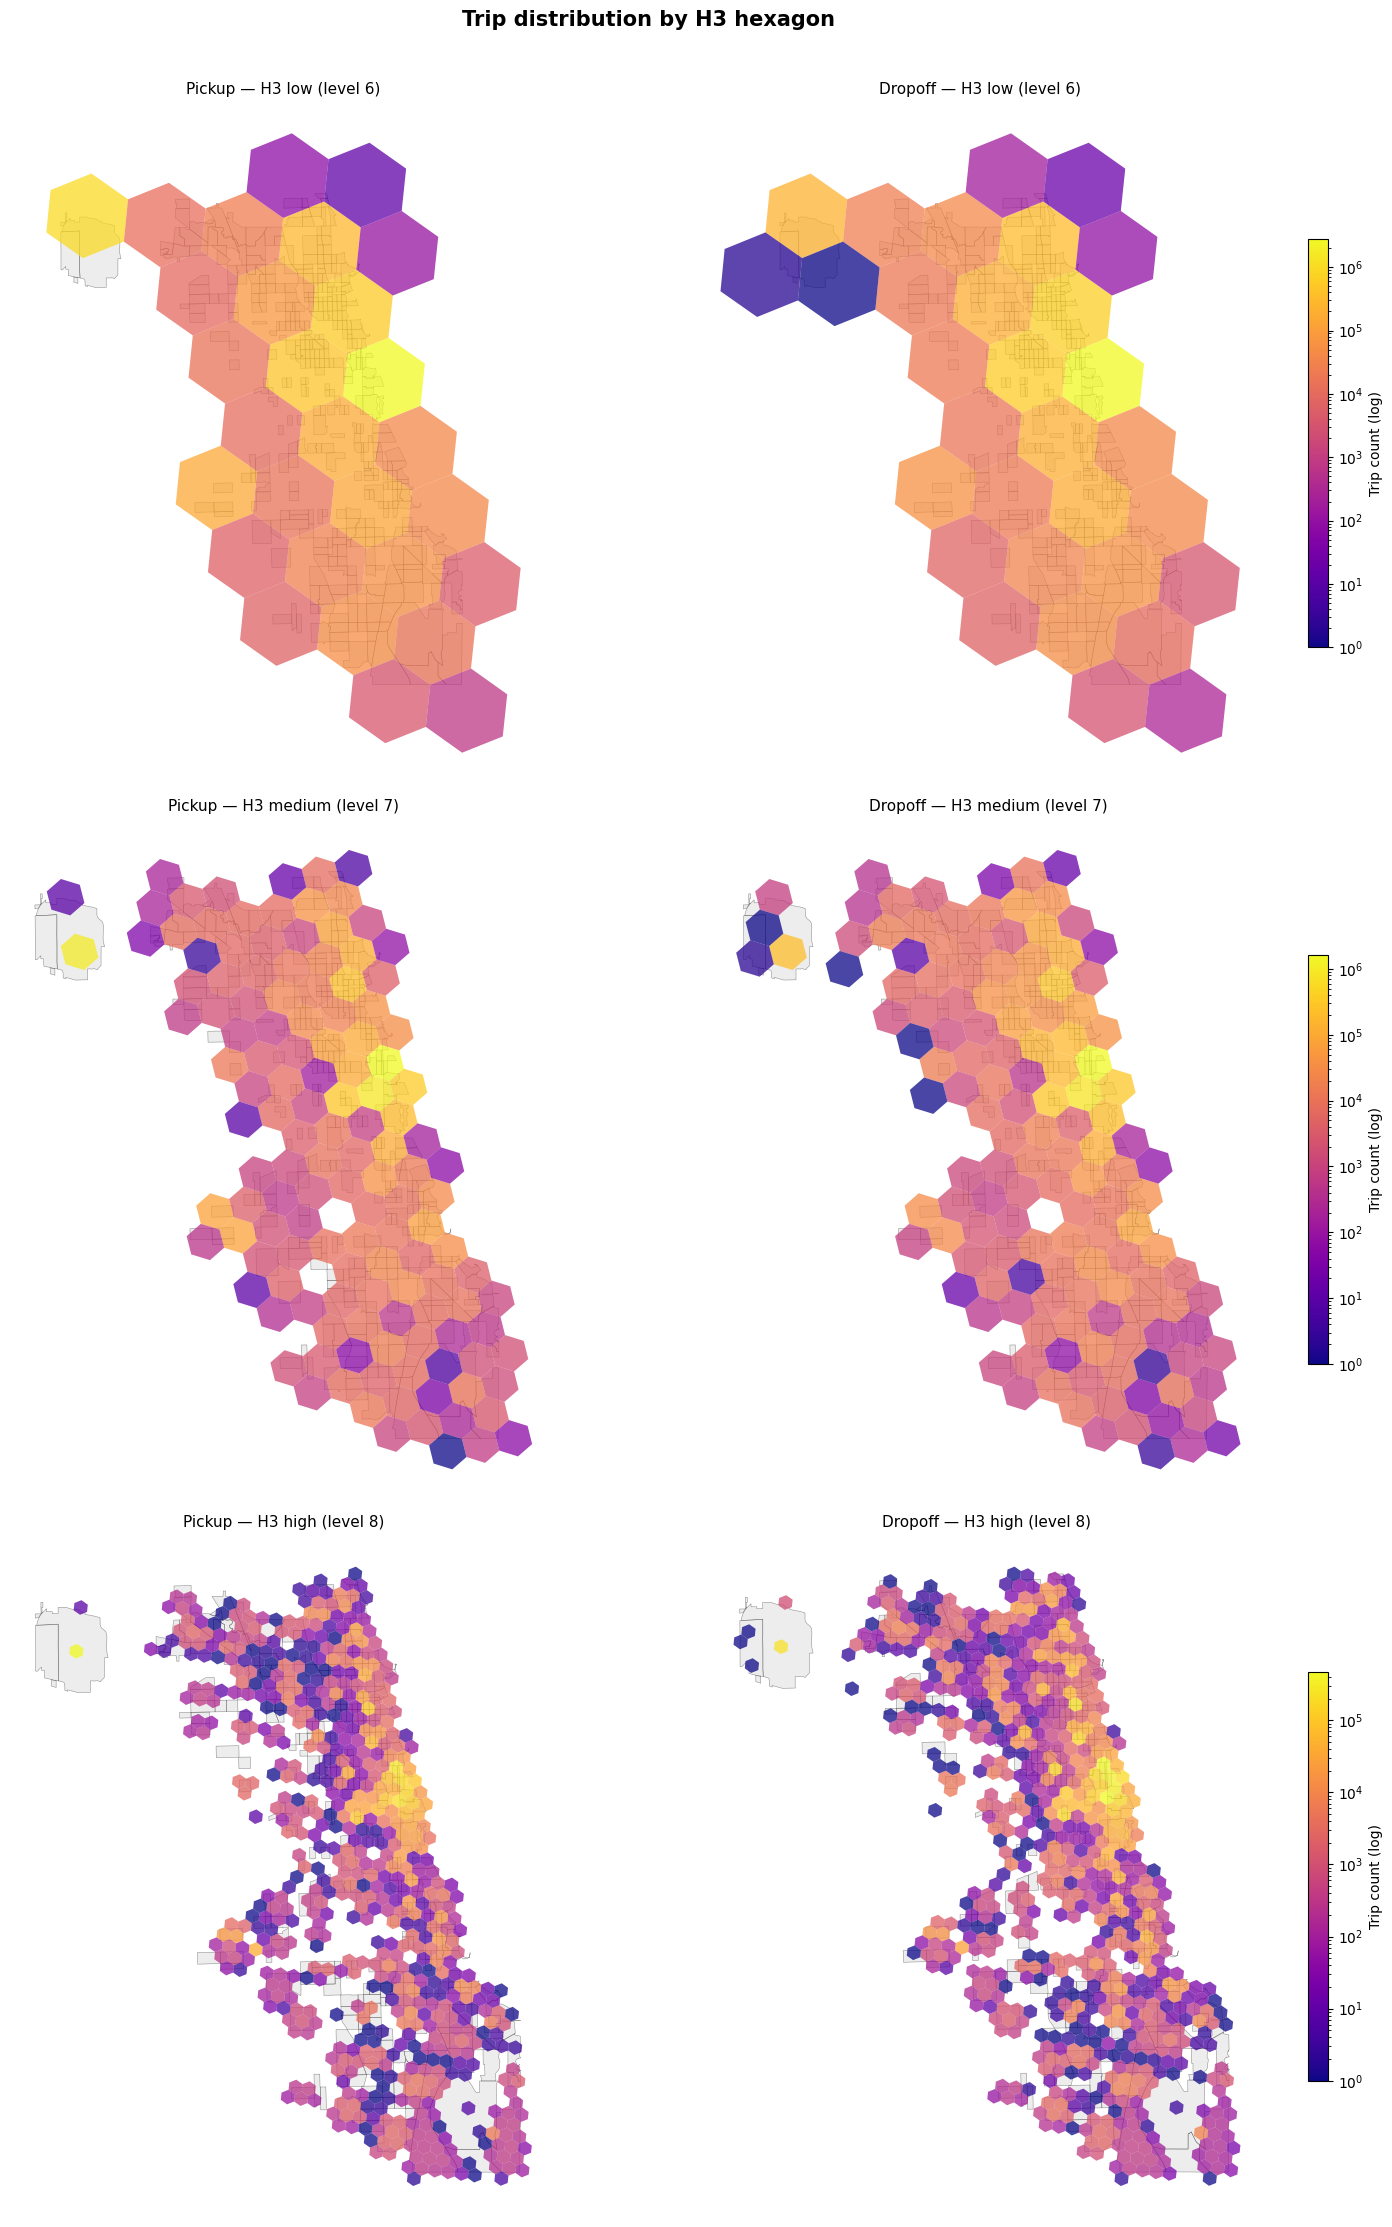

In [25]:
from matplotlib.colors import LogNorm

# Tracts that actually appear in the data (union of pickup + dropoff)
tracts_with_trips = set(
    raw_data["pickup_census_tract"].dropna().apply(lambda x: str(int(float(x))))
) | set(
    raw_data["dropoff_census_tract"].dropna().apply(lambda x: str(int(float(x))))
)
active_tracts = tracts[tracts[TRACT_COL].isin(tracts_with_trips)]

# H3 choropleths — one row per resolution, pickup / dropoff side by side
fig, axes = plt.subplots(3, 2, figsize=(16, 22))

for row_idx, (res_name, res_level) in enumerate(resolutions.items()):
    for col_idx, direction in enumerate(('pickup', 'dropoff')):
        ax = axes[row_idx, col_idx]

        counts = raw_data[f'{direction}_h3_{res_name}_resolution'].value_counts().dropna()

        # Build H3 GeoDataFrame for cells that have at least one trip
        polys = [
            Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(cell)])
            for cell in counts.index
        ]
        hex_gdf = gpd.GeoDataFrame(
            {'count': counts.values, 'geometry': polys}, crs=4326
        )

        # Base layer: only census tract outlines for tracts that have trips
        active_tracts.plot(ax=ax, facecolor='lightgray', edgecolor='black',
                           linewidth=0.4, alpha=0.4)

        # H3 layer coloured by trip count
        hex_gdf.plot(
            ax=ax, column='count', cmap='plasma',
            norm=LogNorm(vmin=1, vmax=counts.max()),
            legend=(col_idx == 1),
            legend_kwds={'label': 'Trip count (log)', 'shrink': 0.6},
            alpha=0.75, edgecolor='none'
        )

        ax.set_title(
            f'{direction.capitalize()} — H3 {res_name} (level {res_level})',
            fontsize=11
        )
        ax.set_axis_off()

plt.suptitle('Trip distribution by H3 hexagon', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [26]:
# write cleaned dataframe into .parquet file
raw_data.to_csv("data/trips/01_04_trips_clean.csv",index=None)